In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
from tensorflow.keras import models,layers

In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import matplotlib.pyplot as plt

In [6]:
batch_size=32
image_size=300

In [7]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "lemon_dataset",
    seed=123,
    shuffle=True,
    batch_size=batch_size,
    image_size=(image_size,image_size),
)

Found 2528 files belonging to 3 classes.


In [8]:
dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
class_names = dataset.class_names

In [10]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 300, 300, 3)
[0 0 2 2 2 1 0 2 1 0 2 2 2 0 2 2 2 2 0 2 0 1 2 2 2 1 2 2 2 2 0 2]


In [11]:
len(dataset)

79

In [12]:
79*32

2528

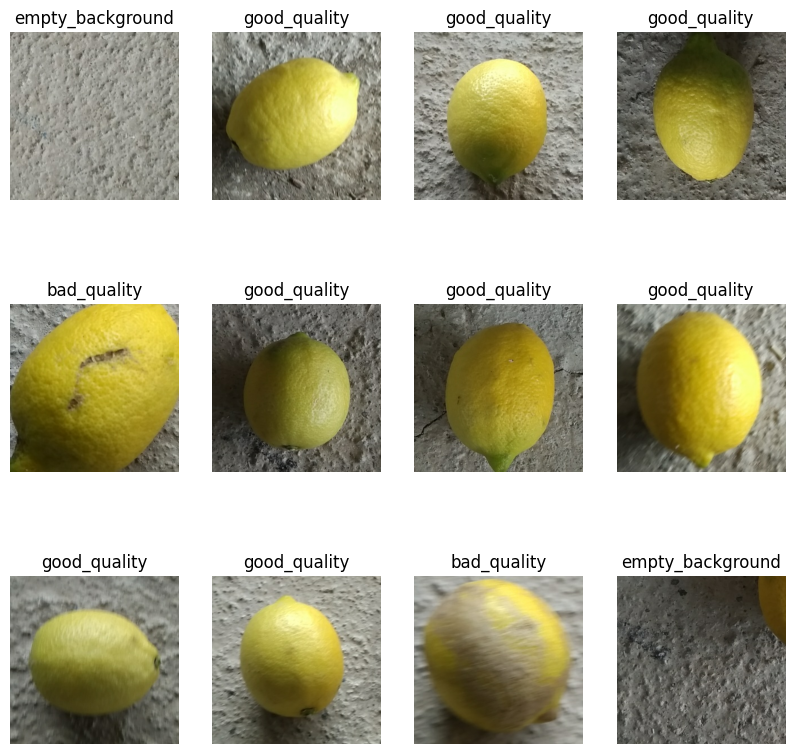

In [13]:
plt.figure(figsize=(10,10))
for image_batch,labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")    

In [14]:
ds_size=len(dataset)

In [15]:
len(dataset.take(63))

63

In [16]:
def split_dataset(dataset,train_split=0.8,test_split=0.1,val_split=0.1,shuffle=True,shuffle_size=10000):
    assert(train_split+test_split+val_split) == 1

    if shuffle:
        dataset = dataset.shuffle(shuffle_size,seed=12)
    train_size=int(ds_size*train_split)
    val_size=int(ds_size*val_split)

    train_ds = dataset.take(train_size)
    val_ds=dataset.skip(train_size).take(val_size)
    test_ds=dataset.skip(train_size).skip(val_size)

    return train_ds,test_ds,val_ds

In [17]:
train_ds, test_ds, val_ds=split_dataset(dataset)

In [18]:
len(train_ds)

63

In [18]:
len(val_ds)

7

In [19]:
len(test_ds)

9

In [20]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [21]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(image_size, image_size),
    tf.keras.layers.Rescaling(1./255),
])

In [22]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

In [23]:
trans_ds=train_ds.map(lambda x,y:(data_augmentation(x,training=True),y)).prefetch(buffer_size=tf.data.AUTOTUNE)

In [26]:
channel=3
n_classes=3

In [27]:
input_shape=(batch_size,image_size,image_size,channel)
model=models.Sequential([resize_and_rescale,layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=input_shape),
                         layers.MaxPooling2D((2,2)),
                         layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
                         layers.MaxPooling2D((2,2)),
                         layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
                         layers.MaxPooling2D((2,2)),
                         layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
                         layers.MaxPooling2D((2,2)),
                         layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
                         layers.Flatten(),
                         layers.Dense(64,activation='relu'),
                         layers.Dense(n_classes,activation='softmax'),
                        ])

In [28]:
model.build(input_shape=input_shape)

In [29]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 300, 300, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 298, 298, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 149, 149, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (32, 147, 147, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 73, 73, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (32, 71, 71, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (32, 35, 35, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (32, 33, 33, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (32, 16, 16, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (32, 14, 14, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (32, 12544)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (32, 64)                    │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 933,251 (3.56 MB)

 Trainable params: 933,251 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy']
             )

In [31]:
history=model.fit(
    train_ds,
    batch_size=batch_size,
    validation_data=val_ds,
    verbose=1,
    epochs=30
    )

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7733 - loss: 0.4855 - val_accuracy: 0.8839 - val_loss: 0.2852
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8581 - loss: 0.3395 - val_accuracy: 0.8705 - val_loss: 0.3046
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8824 - loss: 0.2822 - val_accuracy: 0.8929 - val_loss: 0.2482
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9172 - loss: 0.1980 - val_accuracy: 0.9509 - val_loss: 0.1245
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9479 - loss: 0.1430 - val_accuracy: 0.9688 - val_loss: 0.0842
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9504 - loss: 0.1424 - val_accuracy: 0.8661 - val_loss: 0.3481
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9588 - loss: 0.1090 - val_accuracy: 0.9286 - val_loss: 0.1580
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9633 - loss: 0.1068 - val_accuracy: 0.9821 - val_loss:

In [32]:
scores=model.evaluate(test_ds)

9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 405ms/step - accuracy: 0.9931 - loss: 0.0398


In [35]:
scores

[0.03975445032119751, 0.9930555820465088]

In [37]:
history

In [38]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 63}

In [40]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [41]:
acc=history.history['accuracy']

In [49]:
val_acc=history.history['val_accuracy']

In [50]:
loss=history.history['loss']

In [51]:
val_loss=history.history['val_loss']

In [52]:
epochs=30

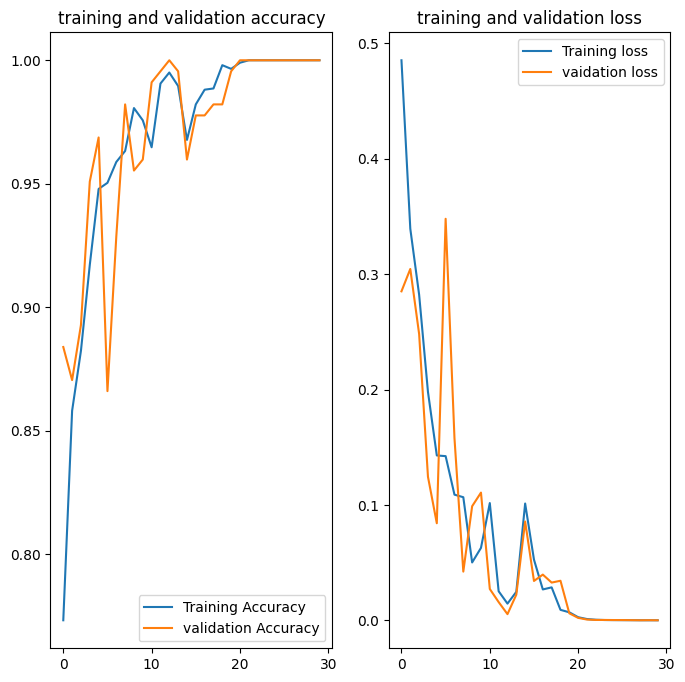

In [53]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epochs),acc,label='Training Accuracy')
plt.plot(range(epochs),val_acc,label='validation Accuracy')
plt.legend(loc='lower right')
plt.title('training and validation accuracy')

plt.subplot(1,2,2)
plt.plot(range(epochs),loss,label='Training loss')
plt.plot(range(epochs),val_loss,label='vaidation loss')
plt.legend(loc='upper right')
plt.title('training and validation loss')
plt.show()

first image to predict
actual label good_quality
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
predicted label good_quality


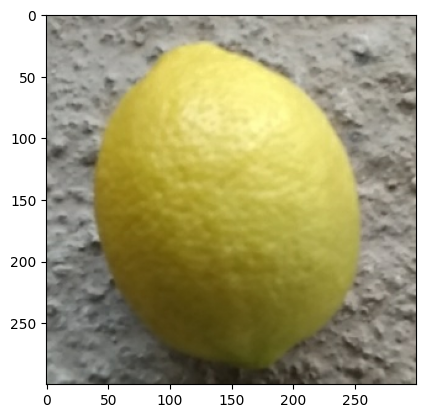

In [59]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype('uint8')
    first_label=labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label",class_names[first_label])
    
    batch_prediction=model.predict(images_batch)
    print("predicted label",class_names[np.argmax(batch_prediction[0])])

In [61]:
model.save("lemon.h5")